## 1. Import Library yang Dibutuhkan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score

## 2. Import Dataset

In [ ]:
df = pd.read_excel('Draft Dataset ETS.xlsx')
df.head()

,Provinsi,Jumlah Penduduk (Ribu),Jumlah Tenaga Kesehatan,Jumlah Fasilitas Kesehatan,Rasio Jenis Kelamin Penduduk,Persentase Penduduk Penerima BPJS Kesehatan,Persentase Rumah Tangga Sanitasi Layak,Persentase Rumah Tangga Sumber Air Minum Layak,Persentase Rumah Tangga Hunian Layak,Laju Pertumbuhan Penduduk per Tahun,Jumlah Penduduk Miskin (Ribu)
0,Aceh,5626.0,623,452,100.9,97.79,82.21,92.06,71.15,1.37,703.33
1,Sumatera Utara,15785.8,1634,827,100.8,67.91,87.47,93.24,76.89,1.37,1128.06
2,Sumatera Barat,5914.3,1090,363,101.5,75.12,74.59,87.26,63.70,1.41,312.30
3,Riau,6811.2,1823,323,104.3,70.49,91.21,92.17,80.22,1.34,475.57
4,Jambi,3768.5,2131,253,103.2,61.04,85.88,82.46,68.42,1.28,261.25


## 3. Eksplorasi Data Awal

In [ ]:
print("Jumlah data:", df.shape[0])
print("Jumlah fitur numerik:", df.shape[1])
print()
display(df.describe().T)

Jumlah data: 38
Jumlah fitur numerik: 11



,count,mean,std,min,25%,50%,75%,max
Jumlah Penduduk (Ribu),38.0,7485.226316,11416.685669,549.70,1531.6750,3775.000,6586.9750,50759.00
Jumlah Tenaga Kesehatan,38.0,1918.052632,981.638783,246.00,1030.0000,1993.500,2393.5000,4122.00
Jumlah Fasilitas Kesehatan,38.0,357.473684,347.937299,75.00,149.7500,253.500,382.5000,1542.00
Rasio Jenis Kelamin Penduduk,38.0,104.047368,3.848393,97.80,101.0500,103.250,105.2750,114.00
Persentase Penduduk Penerima BPJS Kesehatan,38.0,74.945000,11.215337,40.12,69.4100,73.930,83.4150,97.79
Persentase Rumah Tangga Sanitasi Layak,38.0,82.958158,14.960211,16.34,81.1525,85.990,90.1250,98.20
Persentase Rumah Tangga Sumber Air Minum Layak,38.0,87.607895,11.614875,32.89,83.2925,89.935,94.8975,99.98
Persentase Rumah Tangga Hunian Layak,38.0,65.039737,16.040212,9.53,59.0500,68.600,75.5275,88.31
Laju Pertumbuhan Penduduk per Tahun,38.0,1.289474,0.383448,0.23,1.1350,1.340,1.4475,2.67
Jumlah Penduduk Miskin (Ribu),38.0,614.728947,921.595498,42.45,156.8425,301.750,673.1500,3804.29


## 4. Visualisasi Awal Fitur Penting

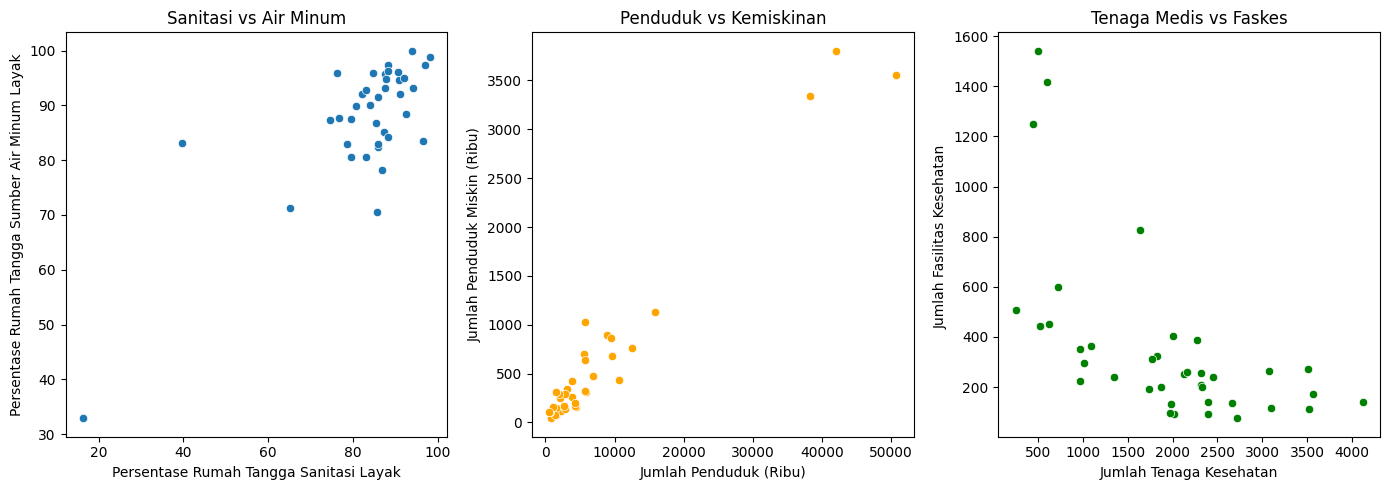

In [ ]:
# Mengatur ukuran kanvas
plt.figure(figsize=(14, 5))

# Plot 1: Kualitas Infrastruktur Dasar
plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='Persentase Rumah Tangga Sanitasi Layak', y='Persentase Rumah Tangga Sumber Air Minum Layak')
plt.title('Sanitasi vs Air Minum')

# Plot 2: Demografi vs Kemiskinan
plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='Jumlah Penduduk (Ribu)', y='Jumlah Penduduk Miskin (Ribu)', color='orange')
plt.title('Penduduk vs Kemiskinan')

# Plot 3: Tenaga Kesehatan vs Fasilitas Kesehatan
plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='Jumlah Tenaga Kesehatan', y='Jumlah Fasilitas Kesehatan ', color='green')
plt.title('Tenaga Medis vs Faskes')

plt.tight_layout()
plt.show()

## 5. Melakukan Preprocessing

In [ ]:
# 1. Pisahkan kolom identitas (Provinsi) agar tidak ikut diolah
kolom_fitur = df.drop('Provinsi', axis=1) # Ini berisi 10 variabel bebas
kolom_provinsi = df['Provinsi']           # Simpan ini untuk digabungkan lagi nanti di hasil akhir

# 2. Lakukan Standarisasi
scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(kolom_fitur)

# 3. Kembalikan ke dalam format DataFrame Pandas agar rapi dan mudah dibaca
df_scaled = pd.DataFrame(fitur_scaled, columns=kolom_fitur.columns)

# Cek 5 data pertama yang sudah distandarisasi
display(df_scaled.head())

,Jumlah Penduduk (Ribu),Jumlah Tenaga Kesehatan,Jumlah Fasilitas Kesehatan,Rasio Jenis Kelamin Penduduk,Persentase Penduduk Penerima BPJS Kesehatan,Persentase Rumah Tangga Sanitasi Layak,Persentase Rumah Tangga Sumber Air Minum Layak,Persentase Rumah Tangga Hunian Layak,Laju Pertumbuhan Penduduk per Tahun,Jumlah Penduduk Miskin (Ribu)
0,-0.165038,-1.336985,0.275323,-0.828818,2.064286,-0.050681,0.388456,0.386048,0.212825,0.097429
1,0.736816,-0.293250,1.367571,-0.855152,-0.635686,0.305638,0.491414,0.748702,0.212825,0.564479
2,-0.139446,-0.854864,0.016096,-0.670816,0.015813,-0.566869,-0.030355,-0.084645,0.318542,-0.332563
3,-0.059831,-0.098130,-0.100410,0.066527,-0.402556,0.558990,0.398054,0.959092,0.133537,-0.153025
4,-0.329922,0.219842,-0.304296,-0.223143,-1.256463,0.197929,-0.449165,0.213566,-0.025038,-0.388700


## 6. Menentukan Jumlah Cluster dengan Elbow Method (Tanpa PCA)

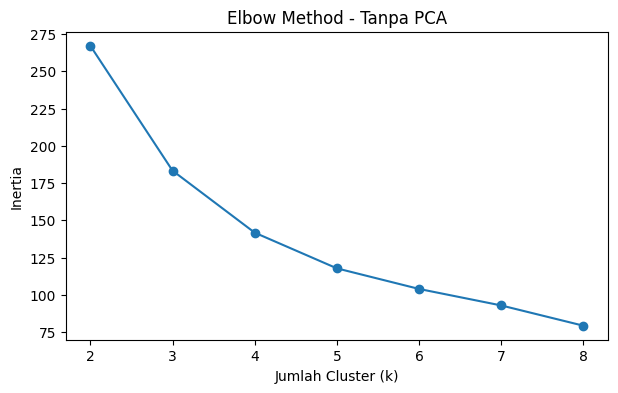

In [ ]:
inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(list(k_range), inertias, marker='o')
plt.title('Elbow Method - Tanpa PCA')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.show()

## 7a. Clustering Tanpa PCA dengan k = 3

In [ ]:
kmeans_raw = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_raw = kmeans_raw.fit_predict(df_scaled)

sil_raw = silhouette_score(df_scaled, labels_raw)
dbi_raw = davies_bouldin_score(df_scaled, labels_raw)

print(f"Silhouette Score (tanpa PCA): {sil_raw:.4f}")
print(f"Davies-Bouldin Index (tanpa PCA): {dbi_raw:.4f}")

Silhouette Score (tanpa PCA): 0.5153
Davies-Bouldin Index (tanpa PCA): 0.6387


### Visualisasi hasil clustering tanpa PCA

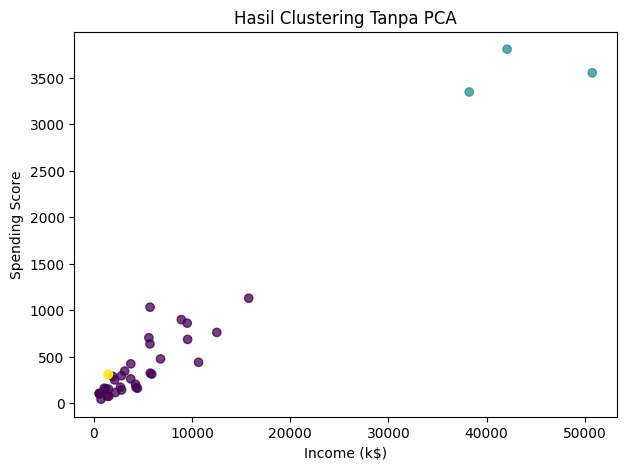

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(df['Jumlah Penduduk (Ribu)'], df['Jumlah Penduduk Miskin (Ribu)'], c=labels_raw, alpha=0.75)
plt.title('Hasil Clustering Tanpa PCA')
plt.xlabel('Income (k$)')
plt.ylabel('Spending Score')
plt.show()

## 8. PCA: Reduksi Dimensi Menjadi 2 Komponen

In [ ]:
pca = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(df_scaled)

print("Shape sebelum PCA :", df_scaled.shape)
print("Shape sesudah PCA :", df_pca.shape)
print()
print("Explained variance ratio:")
for i, ev in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {ev:.4f}")
print(f"Total explained variance 2 PC: {pca.explained_variance_ratio_.sum():.4f}")


Shape sebelum PCA : (38, 10)
Shape sesudah PCA : (38, 2)

Explained variance ratio:
PC1: 0.4345
PC2: 0.2682
Total explained variance 2 PC: 0.7027


###Loading PCA

In [ ]:
pca = PCA(n_components=2)
pca.fit(df_scaled) # df_scaled adalah dataset yang sudah distandarisasi (tanpa Provinsi)

# 2. Ekstrak PCA Loadings ke dalam DataFrame
loadings = pd.DataFrame(
    pca.components_.T,
    index=df_scaled.columns, # <--- Ini yang disesuaikan: mengambil 10 nama kolom dari datasetmu
    columns=['PC1', 'PC2']
).sort_values(by='PC1', key=np.abs, ascending=False)

# 3. Tampilkan Hasil
print("Tabel Kontribusi Variabel (PCA Loadings):")
display(loadings)

Tabel Kontribusi Variabel (PCA Loadings):


,PC1,PC2
Rasio Jenis Kelamin Penduduk,0.386412,-0.208434
Jumlah Fasilitas Kesehatan,-0.384605,-0.337912
Jumlah Penduduk (Ribu),-0.377862,-0.341764
Jumlah Penduduk Miskin (Ribu),-0.368606,-0.362969
Persentase Rumah Tangga Sumber Air Minum Layak,-0.338392,0.299797
Persentase Rumah Tangga Sanitasi Layak,-0.287599,0.432870
Persentase Rumah Tangga Hunian Layak,-0.278685,0.349719
Jumlah Tenaga Kesehatan,0.271010,0.244336
Laju Pertumbuhan Penduduk per Tahun,0.225484,0.012103
Persentase Penduduk Penerima BPJS Kesehatan,-0.157916,0.366629


Visualisasi data pada ruang PCA (sebelum clustering)

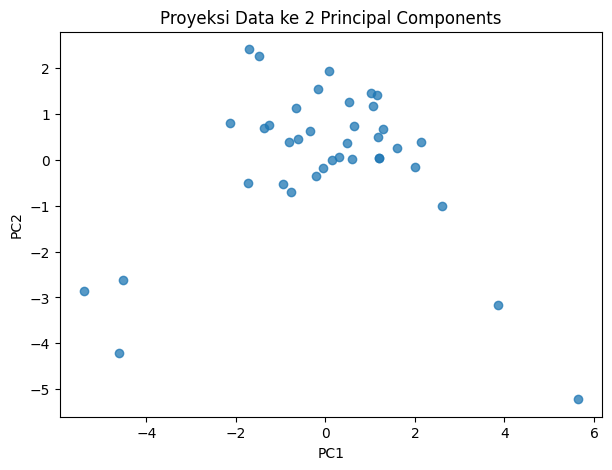

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(df_pca[:,0], df_pca[:,1], alpha=0.75)
plt.title('Proyeksi Data ke 2 Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


## 9.

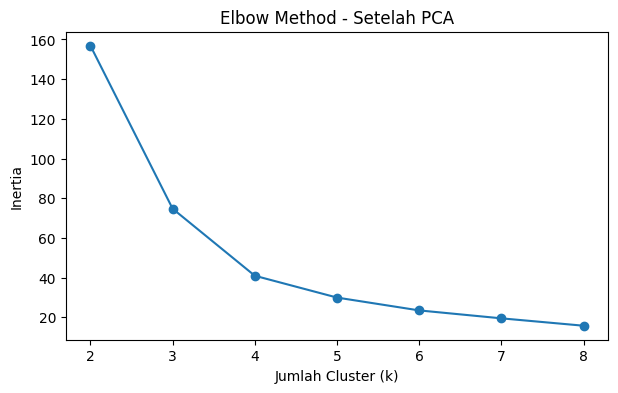

In [ ]:
inertias_pca = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_pca)
    inertias_pca.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(list(k_range), inertias_pca, marker='o')
plt.title('Elbow Method - Setelah PCA')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.show()

## 10.Clustering Setelah PCA

In [ ]:
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(df_pca)

sil_pca = silhouette_score(df_pca, labels_pca)
dbi_pca = davies_bouldin_score(df_pca, labels_pca)

print(f"Silhouette Score (dengan PCA): {sil_pca:.4f}")
print(f"Davies-Bouldin Index (dengan PCA): {dbi_pca:.4f}")


Silhouette Score (dengan PCA): 0.6727
Davies-Bouldin Index (dengan PCA): 0.3794


### Visualisasi hasil clustering dengan PCA

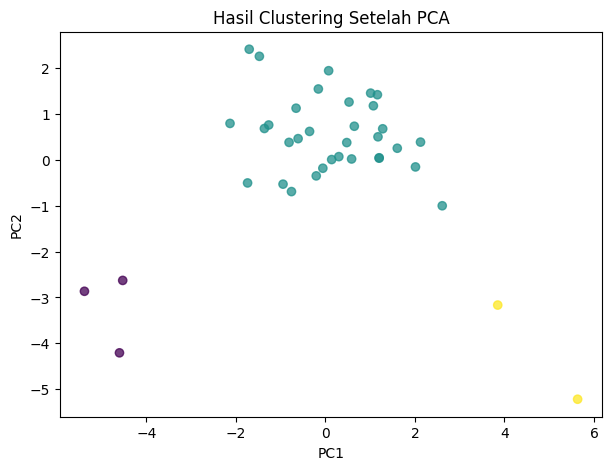

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(df_pca[:,0], df_pca[:,1], c=labels_pca, alpha=0.75)
plt.title('Hasil Clustering Setelah PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

### Visualisasi mendalam hasil clustering dengan PCA

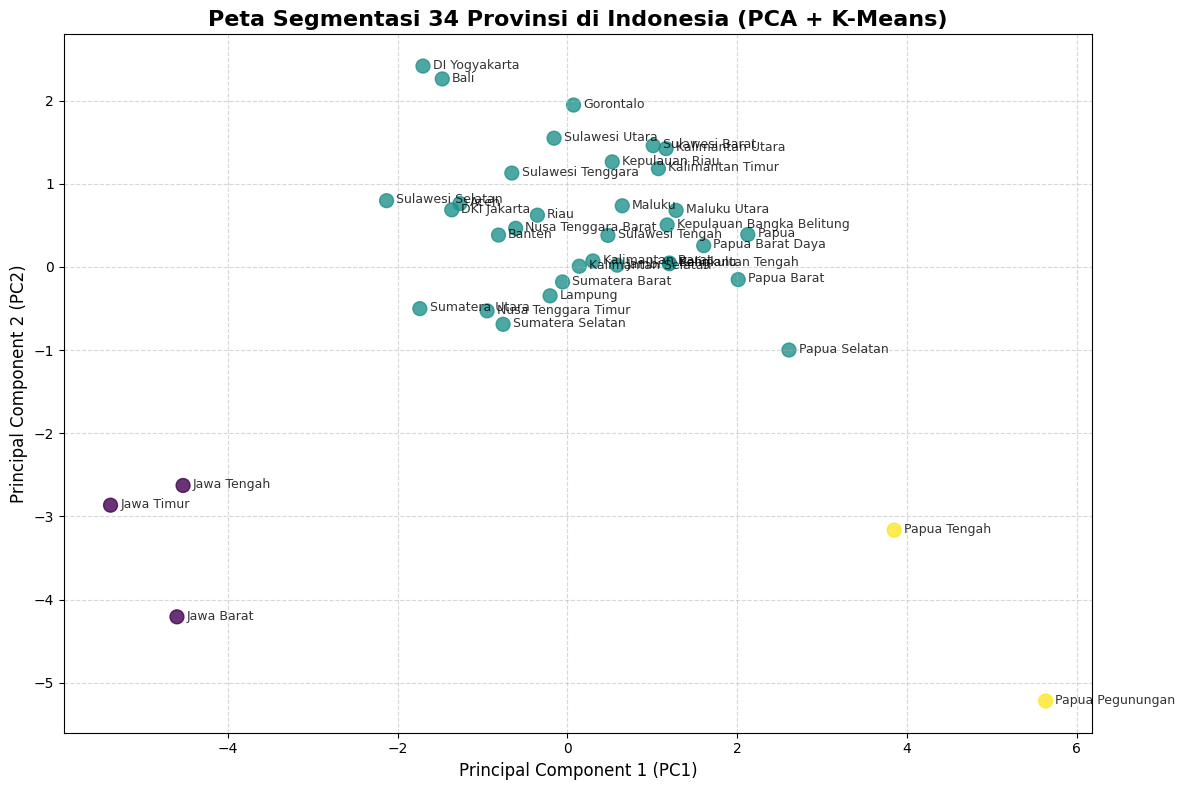

In [ ]:
# 1. Memperbesar ukuran kanvas agar teks punya ruang
plt.figure(figsize=(12, 8))

# Define df_result and Cluster_With_PCA here to fix the NameError
df_result = df.copy()
df_result['Cluster_With_PCA'] = labels_pca

# 2. Membuat scatter plot, tapi sekarang kita warnai (c=...) berdasarkan label klaster
# Parameter s=100 digunakan untuk memperbesar ukuran titiknya
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1],
                      c=df_result['Cluster_With_PCA'],
                      cmap='viridis', # Pilihan warna otomatis
                      alpha=0.8,
                      s=100)

# 3. Menambahkan Judul dan Label Sumbu
plt.title('Peta Segmentasi 34 Provinsi di Indonesia (PCA + K-Means)', fontsize=16, fontweight='bold')
plt.xlabel('Principal Component 1 (PC1)', fontsize=12)
plt.ylabel('Principal Component 2 (PC2)', fontsize=12)

# 4. Looping INTI: Menempelkan teks nama provinsi ke masing-masing titik
daftar_provinsi = df['Provinsi'].tolist()
for i, nama_provinsi in enumerate(daftar_provinsi):
    plt.annotate(nama_provinsi,
                 (df_pca[i, 0], df_pca[i, 1]), # Kordinat titik x dan y
                 fontsize=9,                   # Ukuran huruf
                 alpha=0.8,                    # Transparansi huruf
                 xytext=(7, -2),               # Menggeser teks sedikit ke kanan agar tidak menabrak titik
                 textcoords='offset points')

# 5. Mempercantik tampilan dengan grid
plt.grid(True, linestyle='--', alpha=0.5)

# Menampilkan plot
plt.tight_layout()
plt.show()

## 11. Perbandingan Hasil

In [ ]:
comparison = pd.DataFrame({
    'Metode': ['KMeans tanpa PCA (k=3)', 'PCA + KMeans (k=3)'],
    'Silhouette Score': [sil_raw, sil_pca],
    'Davies-Bouldin Index': [dbi_raw, dbi_pca]
})

# Menampilkan tabel perbandingan
print("Tabel Perbandingan Performa Model:")
display(comparison)

Tabel Perbandingan Performa Model:


,Metode,Silhouette Score,Davies-Bouldin Index
0,KMeans tanpa PCA (k=3),0.515315,0.638688
1,PCA + KMeans (k=3),0.672697,0.379426


## 12. Profil Tiap Cluster

In [ ]:
# 1. Menyalin dataset asli (belum distandarisasi) agar nilainya mudah dipahami (angka asli)
df_result = df.copy()

# 2. Menambahkan kolom hasil klastering
df_result['Cluster_Without_PCA'] = labels_raw
df_result['Cluster_With_PCA'] = labels_pca

# 3. Mengambil daftar nama 10 variabel bebas
kolom_fitur = df_scaled.columns

# 4. Menghitung rata-rata nilai tiap variabel untuk masing-masing klaster
profile_raw = df_result.groupby('Cluster_Without_PCA')[kolom_fitur].mean().round(2)
profile_pca = df_result.groupby('Cluster_With_PCA')[kolom_fitur].mean().round(2)

# 5. Menampilkan hasil
print("=== Profil Cluster TANPA PCA ===")
display(profile_raw)

print("\n=== Profil Cluster DENGAN PCA ===")
display(profile_pca)

=== Profil Cluster TANPA PCA ===


,Jumlah Penduduk (Ribu),Jumlah Tenaga Kesehatan,Jumlah Fasilitas Kesehatan,Rasio Jenis Kelamin Penduduk,Persentase Penduduk Penerima BPJS Kesehatan,Persentase Rumah Tangga Sanitasi Layak,Persentase Rumah Tangga Sumber Air Minum Layak,Persentase Rumah Tangga Hunian Layak,Laju Pertumbuhan Penduduk per Tahun,Jumlah Penduduk Miskin (Ribu)
Cluster_Without_PCA,,,,,,,,,,
0,4556.95,2036.67,274.00,103.75,76.72,86.19,88.61,67.31,1.31,364.90
1,43694.07,516.33,1403.33,100.90,71.89,83.99,96.29,69.96,0.92,3566.61
2,1488.60,2063.50,166.00,113.75,50.17,28.03,58.05,20.24,1.44,309.02



=== Profil Cluster DENGAN PCA ===


,Jumlah Penduduk (Ribu),Jumlah Tenaga Kesehatan,Jumlah Fasilitas Kesehatan,Rasio Jenis Kelamin Penduduk,Persentase Penduduk Penerima BPJS Kesehatan,Persentase Rumah Tangga Sanitasi Layak,Persentase Rumah Tangga Sumber Air Minum Layak,Persentase Rumah Tangga Hunian Layak,Laju Pertumbuhan Penduduk per Tahun,Jumlah Penduduk Miskin (Ribu)
Cluster_With_PCA,,,,,,,,,,
0,43694.07,516.33,1403.33,100.90,71.89,83.99,96.29,69.96,0.92,3566.61
1,4556.95,2036.67,274.00,103.75,76.72,86.19,88.61,67.31,1.31,364.90
2,1488.60,2063.50,166.00,113.75,50.17,28.03,58.05,20.24,1.44,309.02
